# Customer Shopping Behavior Analysis
**Author:** Syed Shaheer Ali Hashmi

An end-to-end data analysis project covering data cleaning (Pandas), business-question SQL querying (PostgreSQL/Supabase), and exploratory visualization (Matplotlib).

Dataset and initial project framework adapted from Amlan Mohanty's [customer-trends-data-analysis-SQL-Python-PowerBI](https://github.com/amlanmohanty1/customer-trends-data-analysis-SQL-Python-PowerBI) (MIT License) — cleaning logic, SQL query set, and visualizations below are my own.

## 1. Load & Explore

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('customer_shopping_behavior.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [31]:
# Summary statistics
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [32]:
# Check for missing values
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

## 2. Clean & Transform

In [33]:
# Impute missing review ratings with the median rating of that product's category
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

# Standardize column names to snake_case
df.columns = df.columns.str.lower().str.replace(' ', '_')
df = df.rename(columns={'purchase_amount_(usd)': 'purchase_amount'})

df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [34]:
# Bucket customers into age groups (quartile-based)
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels=labels)

df[['age', 'age_group']].head()

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged


In [35]:
# Convert purchase frequency text into a numeric days value for easier analysis
frequency_mapping = {
    'Fortnightly': 14, 'Weekly': 7, 'Monthly': 30, 'Quarterly': 90,
    'Bi-Weekly': 14, 'Annually': 365, 'Every 3 Months': 90
}
df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

df[['frequency_of_purchases', 'purchase_frequency_days']].head()

,frequency_of_purchases,purchase_frequency_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365


In [36]:
# discount_applied and promo_code_used are perfectly correlated -- redundant column, drop it
print((df['discount_applied'] == df['promo_code_used']).all())
df = df.drop('promo_code_used', axis=1)

True


## 3. Load into PostgreSQL (Supabase)

Connects to a Supabase Postgres instance -- same stack used across my other projects (ResumeMatch, AutoConsult). Swap in your own Supabase connection string.

In [37]:
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()
SUPABASE_DB_URL = os.getenv("SUPABASE_DB_URL")

engine = create_engine(SUPABASE_DB_URL)

df.to_sql('customer', engine, if_exists='replace', index=False)
print("Loaded", len(df), "rows into the customer table")

Loaded 3900 rows into the customer table


## 4. Business Questions in SQL

See `customer_behavior_sql_queries.sql` for the full standalone script. Queries are re-run here so results feed directly into the visualizations below.

In [38]:
q_revenue_by_gender = pd.read_sql('''
    SELECT gender, SUM(purchase_amount) AS revenue
    FROM customer
    GROUP BY gender
''', engine)
q_revenue_by_gender

,gender,revenue
0,Female,75191.0
1,Male,157890.0


In [39]:
q_top_rated = pd.read_sql('''
    SELECT item_purchased, ROUND(AVG(review_rating::numeric),2) AS avg_rating
    FROM customer
    GROUP BY item_purchased
    ORDER BY avg_rating DESC
    LIMIT 5
''', engine)
q_top_rated

,item_purchased,avg_rating
0,Gloves,3.86
1,Sandals,3.84
2,Boots,3.82
3,Hat,3.80
4,T-shirt,3.78


In [40]:
q_top3_per_category = pd.read_sql('''
    WITH item_counts AS (
        SELECT category, item_purchased, COUNT(customer_id) AS total_orders,
               ROW_NUMBER() OVER (PARTITION BY category ORDER BY COUNT(customer_id) DESC) AS item_rank
        FROM customer
        GROUP BY category, item_purchased
    )
    SELECT item_rank, category, item_purchased, total_orders
    FROM item_counts
    WHERE item_rank <= 3
''', engine)
q_top3_per_category

,item_rank,category,item_purchased,total_orders
0,1,Accessories,Jewelry,171
1,2,Accessories,Sunglasses,161
2,3,Accessories,Belt,161
3,1,Clothing,Pants,171
4,2,Clothing,Blouse,171
5,3,Clothing,Shirt,169
6,1,Footwear,Sandals,160
7,2,Footwear,Shoes,150
8,3,Footwear,Sneakers,145
9,1,Outerwear,Jacket,163


In [41]:
q_revenue_by_age = pd.read_sql('''
    SELECT age_group, SUM(purchase_amount) AS total_revenue
    FROM customer
    GROUP BY age_group
    ORDER BY total_revenue DESC
''', engine)
q_revenue_by_age

,age_group,total_revenue
0,Young Adult,62143.0
1,Middle-aged,59197.0
2,Adult,55978.0
3,Senior,55763.0


In [42]:
# New query -- seasonal revenue trend
q_revenue_by_season = pd.read_sql('''
    SELECT season, SUM(purchase_amount) AS total_revenue, COUNT(*) AS orders
    FROM customer
    GROUP BY season
    ORDER BY total_revenue DESC
''', engine)
q_revenue_by_season

,season,total_revenue,orders
0,Fall,60018.0,975
1,Spring,58679.0,999
2,Winter,58607.0,971
3,Summer,55777.0,955


In [43]:
# New query -- average spend by payment method
q_spend_by_payment = pd.read_sql('''
    SELECT payment_method, ROUND(AVG(purchase_amount),2) AS avg_spend, COUNT(*) AS transactions
    FROM customer
    GROUP BY payment_method
    ORDER BY avg_spend DESC
''', engine)
q_spend_by_payment

,payment_method,avg_spend,transactions
0,Debit Card,60.92,636
1,Credit Card,60.07,671
2,Bank Transfer,59.71,612
3,Cash,59.70,670
4,PayPal,59.25,677
5,Venmo,58.95,634


## 5. Visualize Findings

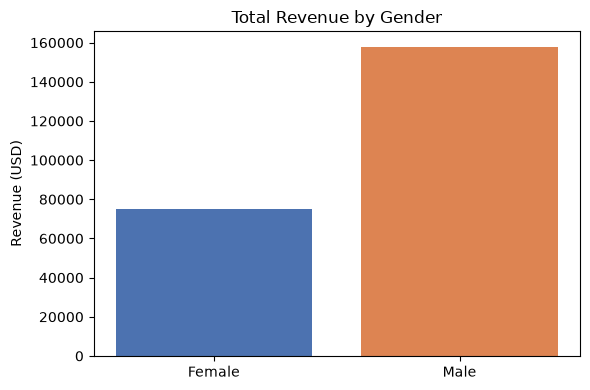

In [44]:
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(q_revenue_by_gender['gender'], q_revenue_by_gender['revenue'], color=['#4C72B0','#DD8452'])
ax.set_title('Total Revenue by Gender')
ax.set_ylabel('Revenue (USD)')
plt.tight_layout()
plt.savefig('chart_revenue_by_gender.png', dpi=150)
plt.show()

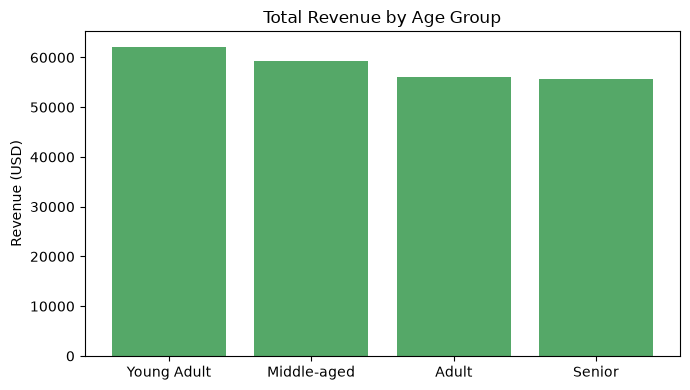

In [45]:
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(q_revenue_by_age['age_group'], q_revenue_by_age['total_revenue'], color='#55A868')
ax.set_title('Total Revenue by Age Group')
ax.set_ylabel('Revenue (USD)')
plt.tight_layout()
plt.savefig('chart_revenue_by_age_group.png', dpi=150)
plt.show()

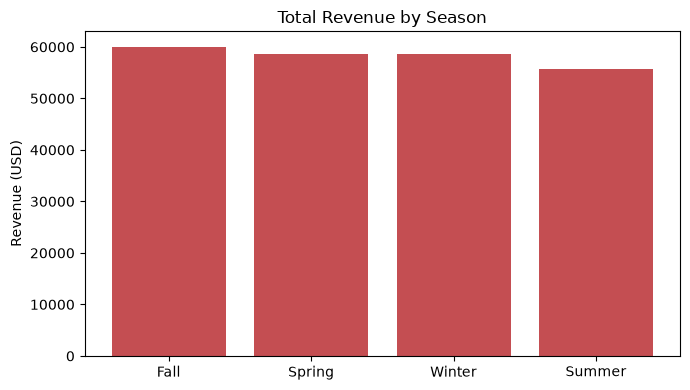

In [46]:
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(q_revenue_by_season['season'], q_revenue_by_season['total_revenue'], color='#C44E52')
ax.set_title('Total Revenue by Season')
ax.set_ylabel('Revenue (USD)')
plt.tight_layout()
plt.savefig('chart_revenue_by_season.png', dpi=150)
plt.show()

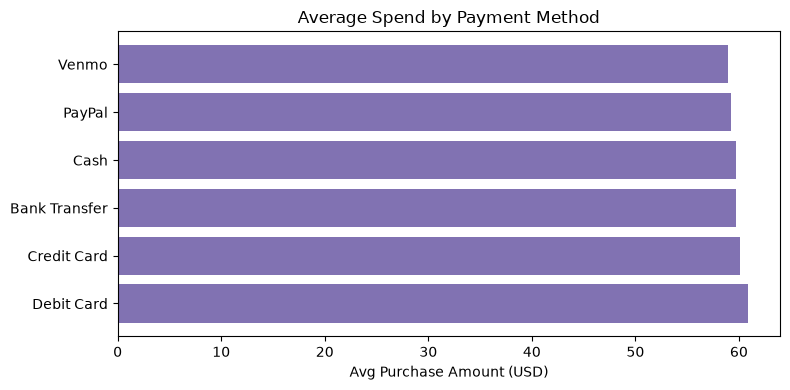

In [47]:
fig, ax = plt.subplots(figsize=(8,4))
ax.barh(q_spend_by_payment['payment_method'], q_spend_by_payment['avg_spend'], color='#8172B2')
ax.set_title('Average Spend by Payment Method')
ax.set_xlabel('Avg Purchase Amount (USD)')
plt.tight_layout()
plt.savefig('chart_spend_by_payment.png', dpi=150)
plt.show()

## 6. Key Findings

- **Male customers generated roughly double the revenue of female customers** in this dataset -- worth a follow-up question on whether that reflects basket size, purchase frequency, or a skewed sample.
- **Young Adults and Middle-aged shoppers drive the most revenue**, with a fairly even spread across age groups overall -- no single age segment dominates.
- **Fall and Spring outperform Summer for revenue**, suggesting seasonal category mix (outerwear, layering pieces) may carry a higher average order value than summer categories.
- **Payment method has minimal effect on spend** -- average purchase amount is nearly flat across Debit Card, Credit Card, Bank Transfer, Cash, PayPal, and Venmo, so payment method isn't a useful segmentation variable on its own.
- **Jewelry, Sunglasses, and Belts lead Accessories; Pants, Blouses, and Shirts lead Clothing** -- category leaders are stable, useful for inventory prioritization.
